# Titanic

## 1. Problem Definition

## 2. Data Collection and Cleaning

### 1. Download and Import the dataset

In [1]:
import pandas as pd

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df = pd.read_csv("../datasets/bmw.csv")
print(df)

           model  year  price transmission  mileage fuelType  tax   mpg  \
0       5 Series  2014  11200    Automatic    67068   Diesel  125  57.6   
1       6 Series  2018  27000    Automatic    14827   Petrol  145  42.8   
2       5 Series  2016  16000    Automatic    62794   Diesel  160  51.4   
3       1 Series  2017  12750    Automatic    26676   Diesel  145  72.4   
4       7 Series  2014  14500    Automatic    39554   Diesel  160  50.4   
...          ...   ...    ...          ...      ...      ...  ...   ...   
10776         X3  2016  19000    Automatic    40818   Diesel  150  54.3   
10777   5 Series  2016  14600    Automatic    42947   Diesel  125  60.1   
10778   3 Series  2017  13100       Manual    25468   Petrol  200  42.8   
10779   1 Series  2014   9930    Automatic    45000   Diesel   30  64.2   
10780         X1  2017  15981    Automatic    59432   Diesel  125  57.6   

       engineSize  
0             2.0  
1             2.0  
2             3.0  
3             1.5  

Save dataset

In [ ]:
print(df.size)

97029


In [7]:
df.value_counts()

model     year  price  transmission  mileage  fuelType  tax  mpg    engineSize
X2        2019  26972  Automatic     123      Petrol    145  38.7   2.0           20
2 Series  2019  22646  Manual        123      Petrol    145  52.3   1.5           15
                20980  Manual        1000     Petrol    145  52.3   1.5           13
X2        2019  29770  Automatic     123      Diesel    145  48.7   2.0            6
2 Series  2019  21773  Automatic     123      Diesel    145  49.6   2.0            4
                                                                                  ..
3 Series  2015  10999  Automatic     90018    Diesel    20   70.6   2.0            1
                       Manual        39245    Diesel    20   68.9   2.0            1
                                     55988    Diesel    20   72.4   2.0            1
                                     57693    Petrol    160  44.1   2.0            1
i8        2019  74226  Automatic     10       Hybrid    135  141.2  1.5

Inspect dataset

In [42]:
print(df.head(3))
print()
print(df.info())
print()
print(df.describe())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
None

         Survived      Pclass         Age       SibSp       Parch        Fare
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000
mean     0.38383

### 2. Data Cleaning

#### 1. Missing values

In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
df["Cabin"].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [14]:
df["Embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [18]:
print(df["Embarked"].value_counts())
print(df["Embarked"].mode())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
0    S
Name: Embarked, dtype: object


In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

C:\Users\Nitro\AppData\Local\Temp\ipykernel_20580\3238960623.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)


In [20]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

In [23]:
print("Data after handling missing values and dropping columns:")
print(df.head(3))
print("Null count:")
print(df.isnull().sum())

Data after handling missing values and dropping columns:
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
Null count:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


#### 2. Outliers

In [44]:
fare = df["Fare"].quantile([0.25, 0.5, 0.75])
for i in range(3):
	print(fare.iloc[i])

IQR = fare.iloc[2] - fare.iloc[0]
lower_bound = fare.iloc[0] - 1.5 * IQR
upper_bound = fare.iloc[2] + 1.5 * IQR

outliers = df[(df["Fare"] < lower_bound) | (df["Fare"] > upper_bound)]

print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print(f"Number of outliers in Fare: {outliers.shape[0]}")
print("Outliers% in Fare:", outliers.shape[0], " / ", df.shape[0], " = ", (outliers.shape[0] / df.shape[0]) * 100)

7.9104
14.4542
31.0
Lower bound: -26.724, Upper bound: 65.6344
Number of outliers in Fare: 116
Outliers% in Fare: 116  /  891  =  13.019079685746352


In [45]:
df = df[(df["Fare"] >= lower_bound) & (df["Fare"] <= upper_bound)]
print(f"Data shape after removing outliers: {df.shape}")

Data shape after removing outliers: (775, 8)


#### 3. Inconsistent format

In [47]:
df = pd.get_dummies(df, columns=["Sex"])

## 3. EDA

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
print(df.head(3))
print()
print(df.info())
print()
print(df.describe())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
None

         Survived      Pclass         Age       SibSp       Parch        Fare
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000
mean     0.38383

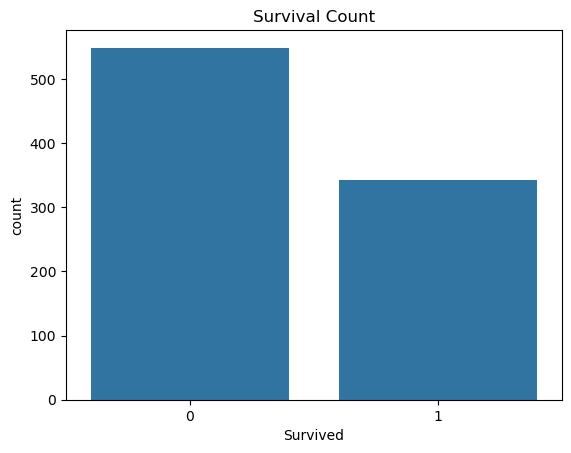

In [25]:
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

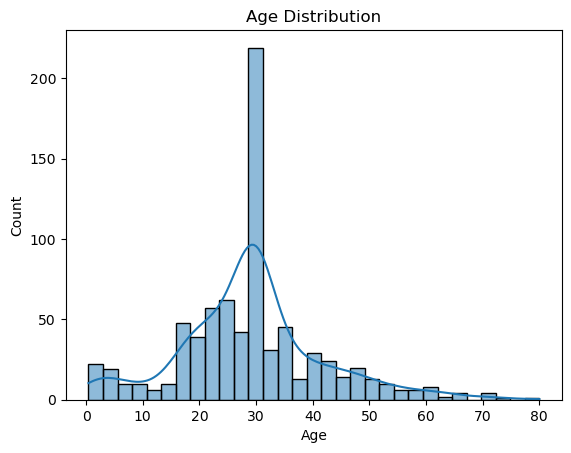

In [48]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

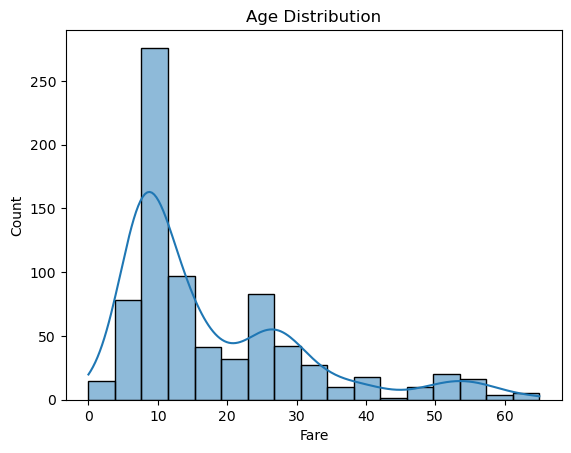

In [49]:
sns.histplot(df["Fare"], kde=True)
plt.title("Age Distribution")
plt.show()

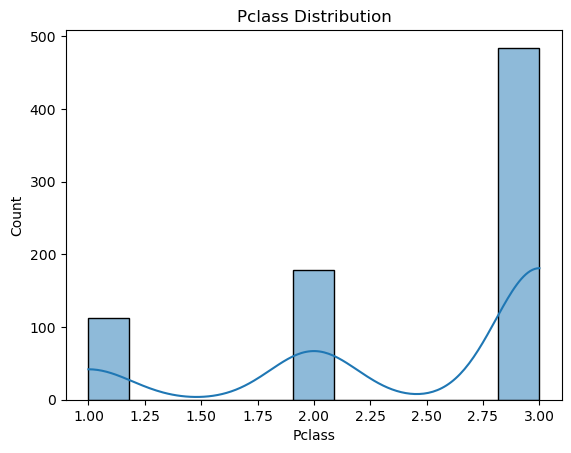

In [50]:
sns.histplot(df["Pclass"], kde=True)
plt.title("Pclass Distribution")
plt.show()

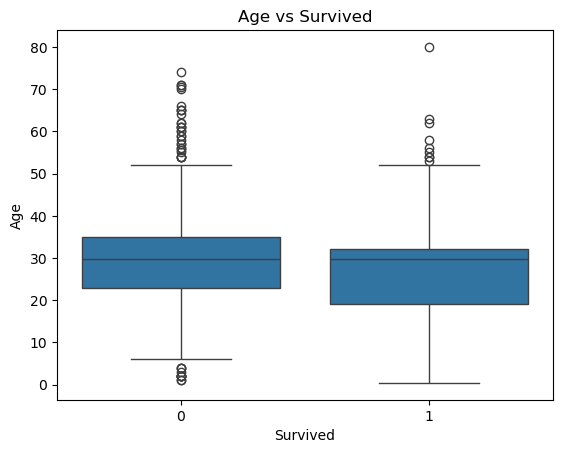

In [51]:
sns.boxplot(x="Survived", y="Age", data=df)
plt.title("Age vs Survived")
plt.show()

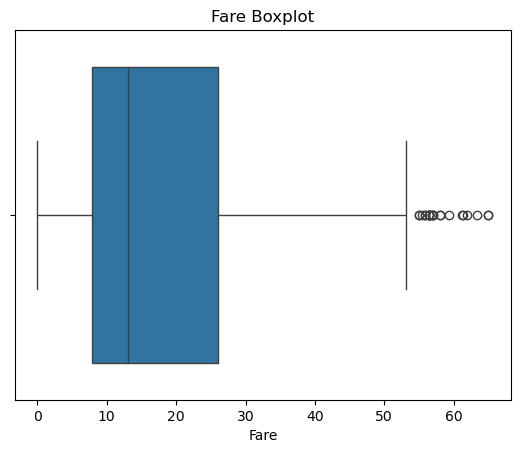

In [54]:
sns.boxplot(x=df["Fare"])
plt.title("Fare Boxplot")
plt.show()

## 4. Feature Engineering

## 5. Model Selection

## 6. Training

## 7. Evaluation

## 8. Hyperparameter Tuning